# Sistema hibrido final de recomendacion y creacion de rutas

Este notebook integra los bloques principales desarrollados en fases anteriores del TFM:

- recomendacion basada en contenido con TF-IDF
- ranking mediante `score`
- senal de calidad consolidada `quality_signal`
- coherencia geografica mediante `cluster_geo`
- algoritmo greedy con restricciones para construir la ruta

La idea de esta fase es pasar de modulos separados a un flujo hibrido unico y explicable.

El pipeline final tendra dos capas principales:

1. seleccion y scoring de candidatos
2. construccion de la ruta bajo restricciones del usuario

Para ello se parte de un dataset enriquecido creado especificamente para esta fase: `pois_barcelona_hibrido.parquet`.

In [37]:
# ==============================
# 1. Carga de librerias
# ==============================

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (10, 5)


In [38]:
# ==============================
# 2. Carga del dataset hibrido
# ==============================

possible_paths = [
    Path('../data/pois_barcelona_hibrido.parquet'),
    Path('data/pois_barcelona_hibrido.parquet')
]
data_path = next((path for path in possible_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError('No se encontro el dataset hibrido. Ejecuta antes src/build_hybrid_dataset.py.')

df = pd.read_parquet(data_path)

print('Dimensiones del dataset hibrido:', df.shape)
print('\nColumnas disponibles:')
print(df.columns.tolist())

display(df.head())


Dimensiones del dataset hibrido: (775, 35)

Columnas disponibles:
['id', 'name', 'category', 'subcategory', 'latitude', 'longitude', 'city', 'description', 'rating', 'match_confidence', 'opening_hours', 'opening_hours_source', 'has_opening_hours', 'is_24_7', 'is_likely_open', 'has_match_confidence', 'score', 'has_valid_source', 'visit_duration', 'tags', 'tags_str', 'content_base', 'content_length', 'has_content_text', 'cluster_geo', 'has_cluster_geo', 'visit_duration_filled', 'rating_filled', 'match_confidence_filled', 'score_norm', 'rating_norm', 'match_confidence_norm', 'visit_duration_norm', 'quality_signal', 'similarity_score']


,id,name,category,subcategory,latitude,longitude,city,description,rating,match_confidence,opening_hours,opening_hours_source,has_opening_hours,is_24_7,is_likely_open,has_match_confidence,score,has_valid_source,visit_duration,tags,tags_str,content_base,content_length,has_content_text,cluster_geo,has_cluster_geo,visit_duration_filled,rating_filled,match_confidence_filled,score_norm,rating_norm,match_confidence_norm,visit_duration_norm,quality_signal,similarity_score
0,3,Biblioteca de Cataluña,cultural,library,41.3810,2.16951,Barcelona,national library,4.2,0.930000,"Mo-Fr 09:00-20:00+; Sa 09:00-14:00+; PH,Su off",OSM,True,False,True,True,3.21900,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor,biblioteca de cataluña cultural library nation...,84,True,1,True,60,4.2,0.930000,0.744064,0.666667,0.925532,0.454545,0.751935,NaN
1,34,Esquerra de l'Eixample,cultural,library,41.3868,2.15205,Barcelona,neighborhood,4.1,0.503766,NaN,NaN,False,False,False,False,2.56796,False,60,"[culture, indoor]",culture|indoor,esquerra de l'eixample cultural library neighb...,67,True,3,True,60,4.1,0.503766,0.404014,0.619048,0.472091,0.454545,0.467984,NaN
2,35,Can Mariner (Barcelona),cultural,library,41.4312,2.16056,Barcelona,masia,4.1,0.650000,"Mo,Fr 15:30-20:00; Tu,Th 09:30-13:30,15:30-20:...",OSM,True,False,True,True,3.06500,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor,can mariner (barcelona) cultural library masia...,74,True,0,True,60,4.1,0.650000,0.663627,0.619048,0.627660,0.454545,0.647087,NaN
3,111,Archivo Histórico de la Ciudad de Barcelona,cultural,library,41.3841,2.17567,Barcelona,archive,4.3,0.503766,NaN,NaN,False,False,False,False,2.68696,False,60,"[culture, indoor]",culture|indoor,archivo histórico de la ciudad de barcelona cu...,83,True,1,True,60,4.3,0.503766,0.466169,0.714286,0.472091,0.454545,0.529087,NaN
4,112,Arxiu Diocesà de Barcelona,cultural,library,41.3837,2.17534,Barcelona,episcopal archive,4.2,0.750000,Mo off; Tu-We 18:00-01:00; Th 18:00-02:00; Fr ...,OSM,True,False,True,True,3.16500,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor,arxiu diocesà de barcelona cultural library ep...,89,True,1,True,60,4.2,0.750000,0.715859,0.666667,0.734043,0.454545,0.706288,NaN


## 3. Variables utiles del sistema hibrido final

El dataset hibrido ya incorpora senales preparadas para integracion:

- `content_base`: texto base para TF-IDF
- `cluster_geo`: cluster geografico persistido
- `quality_signal`: senal estatica combinando `score`, `rating` y `match_confidence`
- `visit_duration_filled`: duracion lista para restricciones de tiempo
- `score_norm`, `rating_norm`, `match_confidence_norm`: señales normalizadas

Esto evita recalcular continuamente la misma preparacion y mejora la trazabilidad del sistema.

In [39]:
# ==============================
# 3. Revision rapida de las variables clave
# ==============================

variables_clave = [
    'category',
    'subcategory',
    'score',
    'quality_signal',
    'cluster_geo',
    'visit_duration_filled',
    'content_base'
]

display(df[variables_clave].head())

print('Nulos en columnas clave:')
display(df[variables_clave].isna().sum().to_frame('nulos'))

print('Distribucion de cluster_geo:')
display(df['cluster_geo'].value_counts(dropna=False).sort_index().to_frame('n_pois'))


,category,subcategory,score,quality_signal,cluster_geo,visit_duration_filled,content_base
0,cultural,library,3.21900,0.751935,1,60,biblioteca de cataluña cultural library nation...
1,cultural,library,2.56796,0.467984,3,60,esquerra de l'eixample cultural library neighb...
2,cultural,library,3.06500,0.647087,0,60,can mariner (barcelona) cultural library masia...
3,cultural,library,2.68696,0.529087,1,60,archivo histórico de la ciudad de barcelona cu...
4,cultural,library,3.16500,0.706288,1,60,arxiu diocesà de barcelona cultural library ep...


Nulos en columnas clave:


,nulos
category,0
subcategory,1
score,0
quality_signal,0
cluster_geo,1
visit_duration_filled,0
content_base,0


Distribucion de cluster_geo:


,n_pois
cluster_geo,
0,65
1,317
2,79
3,137
4,38
5,86
6,52
<NA>,1


## 4. Capa 1: recomendador hibrido de candidatos

Esta capa combina:

- similitud semantica via TF-IDF
- relevancia estatica via `quality_signal`
- filtrado por preferencias del usuario
- proximidad inicial al punto de partida

La similitud puede construirse de dos maneras:

- usando un POI de referencia si el usuario parte de un lugar concreto
- usando una consulta textual derivada de categorias, subcategorias o palabras clave

De este modo el sistema no depende de un unico modo de uso.

In [40]:
# ==============================
# 4. TF-IDF sobre el dataset hibrido
# ==============================

# Vectorizamos el texto consolidado del dataset enriquecido.
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(df['content_base'].fillna(''))

# Serie auxiliar para localizar rapidamente un POI por nombre.
indices = pd.Series(df.index, index=df['name']).drop_duplicates()

print('Shape matriz TF-IDF:', tfidf_matrix.shape)


Shape matriz TF-IDF: (775, 4141)


In [41]:
# ==============================
# 5. Funciones auxiliares
# ==============================

def haversine_km(lat1, lon1, lat2, lon2):
    # Distancia geodesica aproximada entre dos coordenadas.
    r = 6371.0

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = (
        math.sin(delta_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    )

    return 2 * r * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def min_max_normalize(series, fill_value=0.0):
    # Normalizacion robusta para mezclar señales heterogeneas.
    data = pd.Series(series, copy=True)

    if data.notna().sum() == 0:
        return pd.Series(fill_value, index=data.index, dtype=float)

    min_value = data.min(skipna=True)
    max_value = data.max(skipna=True)

    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        return pd.Series(fill_value, index=data.index, dtype=float)

    return ((data - min_value) / (max_value - min_value)).fillna(fill_value)


def construir_query_text(preferences):
    # Creamos una consulta textual sencilla a partir de preferencias del usuario.
    partes = []

    if preferences.get('query_text'):
        partes.append(str(preferences['query_text']))

    if preferences.get('categories'):
        partes.extend(preferences['categories'])

    if preferences.get('subcategories'):
        partes.extend(preferences['subcategories'])

    return ' '.join(str(part).strip() for part in partes if str(part).strip())


def calcular_similitud(preferences, df_input, tfidf_matrix_input, vectorizer_input, indices_input):
    # Permitimos dos modos de obtener similitud: por POI de referencia o por consulta textual.
    similarity_score = pd.Series(0.0, index=df_input.index, dtype=float)

    reference_poi_name = preferences.get('reference_poi_name')
    if reference_poi_name:
        if reference_poi_name not in indices_input:
            raise ValueError(f"El POI de referencia '{reference_poi_name}' no existe en el dataset.")

        idx = indices_input[reference_poi_name]
        similarity_score = pd.Series(cosine_similarity(tfidf_matrix_input[idx], tfidf_matrix_input).flatten(), index=df_input.index)
        similarity_score.loc[idx] = 0.0
        return similarity_score

    query_text = construir_query_text(preferences)
    if query_text:
        query_vector = vectorizer_input.transform([query_text])
        similarity_score = pd.Series(cosine_similarity(query_vector, tfidf_matrix_input).flatten(), index=df_input.index)

    return similarity_score


In [42]:
# ==============================
# 6. Construccion de candidatos hibridos
# ==============================

def construir_candidatos_hibridos(df_input, preferences):
    # Copiamos el dataset para trabajar sin modificar el original.
    candidates = df_input.copy()

    # Calculamos la similitud segun el modo de consulta seleccionado.
    candidates['similarity_score'] = calcular_similitud(
        preferences=preferences,
        df_input=candidates,
        tfidf_matrix_input=tfidf_matrix,
        vectorizer_input=vectorizer,
        indices_input=indices,
    )

    # Filtrado por preferencias del usuario.
    categories = preferences.get('categories') or []
    subcategories = preferences.get('subcategories') or []
    min_rating = preferences.get('min_rating', 0.0)

    if categories:
        candidates = candidates[candidates['category'].isin(categories)]

    if subcategories:
        candidates = candidates[candidates['subcategory'].isin(subcategories)]

    candidates = candidates[candidates['rating'].fillna(0) >= min_rating].copy()

    # Distancia desde el punto inicial para controlar viabilidad.
    start_lat = preferences['start_lat']
    start_lon = preferences['start_lon']
    candidates['distance_from_start_km'] = candidates.apply(
        lambda row: haversine_km(start_lat, start_lon, row['latitude'], row['longitude']),
        axis=1
    )

    max_distance_km = preferences.get('max_distance_km', 6.0)
    candidates = candidates[candidates['distance_from_start_km'] <= max_distance_km].copy()

    # Normalizamos las señales usadas en el score híbrido de candidatos.
    candidates['similarity_norm'] = min_max_normalize(candidates['similarity_score'], fill_value=0.0)
    candidates['quality_norm'] = min_max_normalize(candidates['quality_signal'], fill_value=0.0)
    candidates['start_proximity_norm'] = 1 - min_max_normalize(candidates['distance_from_start_km'], fill_value=0.0)

    weights = preferences.get('candidate_weights', {
        'quality': 0.45,
        'similarity': 0.35,
        'proximity': 0.20,
    })

    # Score híbrido previo a la construcción de ruta.
    candidates['hybrid_candidate_score'] = (
        weights['quality'] * candidates['quality_norm']
        + weights['similarity'] * candidates['similarity_norm']
        + weights['proximity'] * candidates['start_proximity_norm']
    )

    top_k_candidates = preferences.get('top_k_candidates', 30)
    candidates = candidates.sort_values('hybrid_candidate_score', ascending=False).head(top_k_candidates).reset_index(drop=True)

    return candidates


## 5. Capa 2: construccion de la ruta final

Una vez seleccionados los candidatos, el algoritmo de ruta debe decidir el orden de visita teniendo en cuenta:

- proximidad entre POIs consecutivos
- coherencia espacial via `cluster_geo`
- distancia maxima total
- tiempo total disponible
- numero maximo de POIs

Se mantiene un enfoque greedy porque en este punto del proyecto priorizamos explicabilidad, integrabilidad y control de restricciones.

In [43]:
# ==============================
# 7. Algoritmo de ruta hibrido
# ==============================

def scorear_siguientes_pois(candidates, current_point, start_point, current_cluster, preferences):
    # Calculamos distancias dinamicas necesarias para decidir el siguiente POI.
    scored = candidates.copy()
    scored['distance_from_current_km'] = scored.apply(
        lambda row: haversine_km(
            current_point['lat'],
            current_point['lon'],
            row['latitude'],
            row['longitude']
        ),
        axis=1
    )

    scored['return_to_start_km'] = scored.apply(
        lambda row: haversine_km(
            row['latitude'],
            row['longitude'],
            start_point['lat'],
            start_point['lon']
        ),
        axis=1
    )

    scored['candidate_norm'] = min_max_normalize(scored['hybrid_candidate_score'], fill_value=0.0)
    scored['proximity_norm'] = 1 - min_max_normalize(scored['distance_from_current_km'], fill_value=0.0)
    scored['duration_penalty'] = min_max_normalize(scored['visit_duration_filled'], fill_value=0.0)

    if preferences.get('use_cluster_coherence', True) and current_cluster is not None:
        scored['cluster_bonus'] = (scored['cluster_geo'] == current_cluster).astype(float)
    else:
        scored['cluster_bonus'] = 0.0

    weights = preferences.get('route_weights', {
        'candidate_score': 0.55,
        'proximity': 0.30,
        'cluster': 0.10,
        'duration_penalty': 0.05,
    })

    scored['route_utility'] = (
        weights['candidate_score'] * scored['candidate_norm']
        + weights['proximity'] * scored['proximity_norm']
        + weights['cluster'] * scored['cluster_bonus']
        - weights['duration_penalty'] * scored['duration_penalty']
    )

    return scored.sort_values('route_utility', ascending=False)


def construir_ruta_hibrida(candidates, preferences):
    start_point = {'lat': preferences['start_lat'], 'lon': preferences['start_lon']}
    current_point = start_point.copy()
    current_cluster = None

    remaining = candidates.copy()
    route_rows = []
    total_distance_km = 0.0
    total_visit_minutes = 0.0

    max_pois = preferences.get('max_pois', 6)
    max_distance_km = preferences.get('max_distance_km', 6.0)
    max_time_minutes = preferences.get('max_time_minutes', 240)
    max_leg_distance_km = preferences.get('max_leg_distance_km', 2.5)

    while len(route_rows) < max_pois and not remaining.empty:
        ranked = scorear_siguientes_pois(
            candidates=remaining,
            current_point=current_point,
            start_point=start_point,
            current_cluster=current_cluster,
            preferences=preferences,
        )

        next_poi = None
        for _, candidate in ranked.iterrows():
            leg_distance_km = candidate['distance_from_current_km']
            projected_total_distance = total_distance_km + leg_distance_km + candidate['return_to_start_km']
            projected_total_time = total_visit_minutes + candidate['visit_duration_filled']

            if leg_distance_km > max_leg_distance_km:
                continue

            if projected_total_distance > max_distance_km:
                continue

            if projected_total_time > max_time_minutes:
                continue

            next_poi = candidate.copy()
            break

        if next_poi is None:
            break

        total_distance_km += next_poi['distance_from_current_km']
        total_visit_minutes += next_poi['visit_duration_filled']

        next_poi['route_position'] = len(route_rows) + 1
        next_poi['distance_from_previous_km'] = next_poi['distance_from_current_km']
        next_poi['distance_accumulated_km'] = total_distance_km
        next_poi['time_accumulated_min'] = total_visit_minutes

        route_rows.append(next_poi)

        current_point = {'lat': next_poi['latitude'], 'lon': next_poi['longitude']}
        current_cluster = next_poi['cluster_geo']
        remaining = remaining[remaining['id'] != next_poi['id']].copy()

    route_df = pd.DataFrame(route_rows)

    if route_df.empty:
        return route_df, {
            'total_pois': 0,
            'distance_without_return_km': 0.0,
            'return_to_start_km': 0.0,
            'distance_with_return_km': 0.0,
            'total_visit_minutes': 0.0,
            'avg_candidate_score': 0.0,
            'avg_similarity_score': 0.0,
        }

    return_to_start_km = haversine_km(
        current_point['lat'],
        current_point['lon'],
        start_point['lat'],
        start_point['lon'],
    )

    summary = {
        'total_pois': int(len(route_df)),
        'distance_without_return_km': round(float(route_df['distance_from_previous_km'].sum()), 2),
        'return_to_start_km': round(float(return_to_start_km), 2),
        'distance_with_return_km': round(float(route_df['distance_from_previous_km'].sum() + return_to_start_km), 2),
        'total_visit_minutes': round(float(route_df['visit_duration_filled'].sum()), 1),
        'avg_candidate_score': round(float(route_df['hybrid_candidate_score'].mean()), 4),
        'avg_similarity_score': round(float(route_df['similarity_score'].mean()), 4),
    }

    return route_df, summary


def ejecutar_pipeline_hibrido(df_input, preferences):
    candidates = construir_candidatos_hibridos(df_input, preferences)
    route_df, summary = construir_ruta_hibrida(candidates, preferences)
    return candidates, route_df, summary


## 6. Ejemplo de uso del sistema hibrido final

En este ejemplo simulamos un usuario que:

- parte del centro de Barcelona
- busca una experiencia cultural/monumental
- tiene un presupuesto limitado de distancia y tiempo
- y expresa ademas una intencion semantica mediante texto

Con ello el sistema debe:

1. generar candidatos hibridos
2. ordenarlos por relevancia
3. construir una ruta final razonable

In [44]:
# ==============================
# 8. Ejecucion del pipeline hibrido
# ==============================

preferences = {
    'start_lat': 41.3874,
    'start_lon': 2.1686,
    'categories': ['cultural', 'historic', 'monument'],
    'subcategories': [],
    'query_text': 'gaudi architecture basilica museum heritage',
    'reference_poi_name': None,
    'min_rating': 4.0,
    'max_distance_km': 6.0,
    'max_pois': 6,
    'max_time_minutes': 240,
    'max_leg_distance_km': 2.2,
    'top_k_candidates': 25,
    'use_cluster_coherence': True,
    'candidate_weights': {
        'quality': 0.45,
        'similarity': 0.35,
        'proximity': 0.20,
    },
    'route_weights': {
        'candidate_score': 0.55,
        'proximity': 0.30,
        'cluster': 0.10,
        'duration_penalty': 0.05,
    },
}

candidates_df, route_df, route_summary = ejecutar_pipeline_hibrido(df, preferences)

print('Resumen de la ruta hibrida:')
display(pd.DataFrame([route_summary]))

print('Top candidatos hibridos:')
display(candidates_df[[
    'name',
    'category',
    'subcategory',
    'similarity_score',
    'quality_signal',
    'distance_from_start_km',
    'hybrid_candidate_score',
    'cluster_geo'
]].head(15))

print('Ruta final generada:')
display(route_df[[
    'route_position',
    'name',
    'category',
    'subcategory',
    'similarity_score',
    'quality_signal',
    'hybrid_candidate_score',
    'route_utility',
    'cluster_geo',
    'visit_duration_filled',
    'distance_from_previous_km',
    'distance_accumulated_km'
]])


Resumen de la ruta hibrida:


,total_pois,distance_without_return_km,return_to_start_km,distance_with_return_km,total_visit_minutes,avg_candidate_score,avg_similarity_score
0,5,3.12,0.48,3.6,220.0,0.7597,0.1288


Top candidatos hibridos:


,name,category,subcategory,similarity_score,quality_signal,distance_from_start_km,hybrid_candidate_score,cluster_geo
0,Mercado de Santa Caterina,monument,monument,0.122099,0.957524,0.795523,0.817594,1
1,Palacio Moja,monument,monument,0.139859,0.845943,0.533443,0.770916,1
2,Pueblo Español de Barcelona,monument,monument,0.183865,0.822245,2.709973,0.765277,5
3,Arenas de Barcelona,monument,monument,0.157018,0.845068,2.030182,0.753465,5
4,Museu de Cultures del Món,cultural,museum,0.114177,0.905055,1.074126,0.749467,1
5,Casa del Gremi d'Assaonadors,monument,monument,0.120433,0.876374,0.977024,0.741859,1
6,Monumento a Clavé,monument,monument,0.139825,0.861159,1.893850,0.736919,3
7,Hotel 1898,monument,monument,0.147243,0.761383,0.478002,0.718536,1
8,Museu d'Idees i Invents de Barcelona,cultural,museum,0.122891,0.841657,0.978373,0.718387,1
9,Bellesguard,monument,monument,0.136268,0.938897,4.267885,0.712381,2


Ruta final generada:


,route_position,name,category,subcategory,similarity_score,quality_signal,hybrid_candidate_score,route_utility,cluster_geo,visit_duration_filled,distance_from_previous_km,distance_accumulated_km
0,1,Mercado de Santa Caterina,monument,monument,0.122099,0.957524,0.817594,0.804806,1,25,0.795523,0.795523
1,2,Palacio Moja,monument,monument,0.139859,0.845943,0.770916,0.922931,1,25,0.623705,1.419228
5,3,Casa del Gremi d'Assaonadors,monument,monument,0.120433,0.876374,0.741859,0.811862,1,25,0.731991,2.151219
4,4,Museu de Cultures del Món,cultural,museum,0.114177,0.905055,0.749467,0.834977,1,120,0.125614,2.276833
7,5,Hotel 1898,monument,monument,0.147243,0.761383,0.718536,0.721916,1,25,0.845897,3.122730


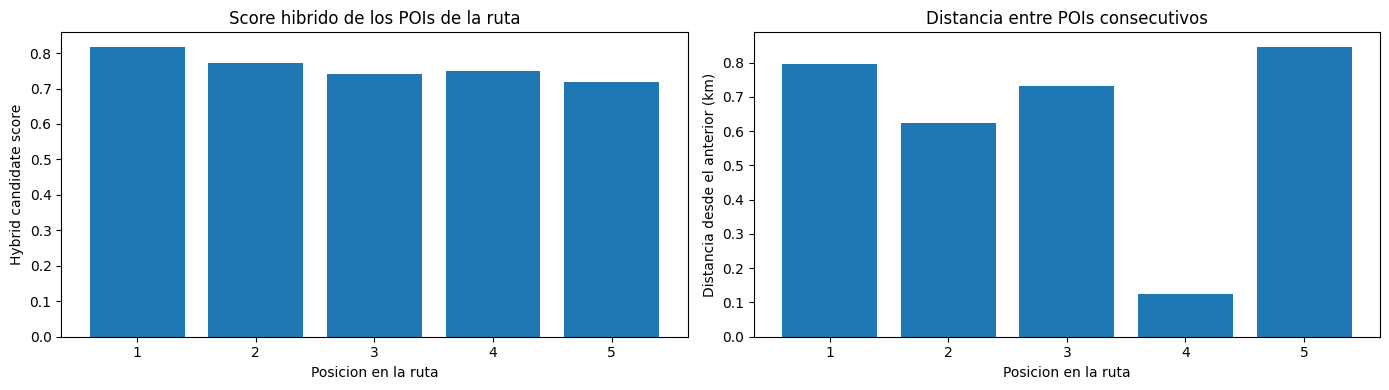

In [45]:
# ==============================
# 9. Analisis visual basico
# ==============================

if not route_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(route_df['route_position'], route_df['hybrid_candidate_score'])
    axes[0].set_title('Score hibrido de los POIs de la ruta')
    axes[0].set_xlabel('Posicion en la ruta')
    axes[0].set_ylabel('Hybrid candidate score')

    axes[1].bar(route_df['route_position'], route_df['distance_from_previous_km'])
    axes[1].set_title('Distancia entre POIs consecutivos')
    axes[1].set_xlabel('Posicion en la ruta')
    axes[1].set_ylabel('Distancia desde el anterior (km)')

    plt.tight_layout()
    plt.show()


## 7. Interpretacion de resultados

Al analizar la salida del sistema conviene revisar:

- si los candidatos mejor puntuados son semanticamente coherentes con la consulta
- si la ruta mantiene continuidad geografica razonable
- si las restricciones de tiempo y distancia se respetan
- si la combinacion de `quality_signal` y similitud produce recomendaciones equilibradas

Si la ruta sale demasiado dispersa, una opcion es:

- aumentar el peso de proximidad o cluster
- reducir `max_leg_distance_km`
- reducir `top_k_candidates`

Si la ruta sale demasiado local pero poco relevante, una opcion es:

- aumentar el peso de calidad o similitud
- relajar ligeramente la restriccion por tramo

## 8. Limitaciones

Aunque esta fase ya integra los modulos principales, todavia existen limites razonables:

- la distancia sigue siendo geodesica y no por red peatonal real
- los pesos del sistema son heuristicas justificadas, no aprendidas con feedback real de usuarios
- el algoritmo greedy no garantiza el optimo global
- la similitud depende de la calidad del texto disponible en `content_base`

Aun asi, para el estado actual del TFM esta solucion es adecuada porque combina explicabilidad, reutilizacion y facilidad de integracion.

## 9. Relacion con backend y siguiente paso

Tras este notebook, el proyecto queda preparado para el siguiente paso practico:

- trasladar esta misma logica al backend
- hacer que la API consuma `pois_barcelona_hibrido.csv` o `pois_barcelona_hibrido.parquet`
- permitir que el frontend envie `query_text`, filtros y restricciones
- devolver una ruta final ya generada por la misma logica hibrida del notebook

En otras palabras, con este bloque ya no estamos solo en una fase previa de exploracion: aqui ya queda diseñado el flujo final del recomendador hibrido del TFM.